ARTI308 - Machine Learning
# Matplotlib Overview

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. Matplotlib makes easy things easy and hard things possible.

Some of the major Pros of Matplotlib are:

* Generally easy to get started for simple plots
* Support for custom labels and texts
* Great control of every element in a figure
* High-quality output in many formats
* Very customizable in general

Matplotlib allows you to create reproducible figures programmatically. Let's learn how to use it! I encourage you just to explore the official Matplotlib web page: http://matplotlib.org/

## Installation 

You'll need to install matplotlib first with either:

    conda install matplotlib 
or
    pip install matplotlib
    
## Importing

Import the `matplotlib.pyplot` module under the name `plt` (the tidy way):

In [1]:
# Import matplotlib's pyplot module as plt - the standard way to create plots in Python
import matplotlib.pyplot as plt

You'll also need to use this line to see plots in the notebook:

In [2]:
# Jupyter magic: display plots inline in the notebook instead of a separate window
%matplotlib inline

That line is only for jupyter notebooks, if you are using another editor, you'll use: **plt.show()** at the end of all your plotting commands to have the figure pop up in another window.

# Basic Example

Let's walk through a very simple example using two numpy arrays:

### Example

Let's walk through a very simple example using two numpy arrays. You can also use lists, but most likely you'll be passing numpy arrays or pandas columns (which essentially also behave like arrays).

** The data we want to plot:**

In [3]:
# Import NumPy for numerical data
import numpy as np
# Create 11 evenly spaced values between 0 and 5 (including both 0 and 5)
x = np.linspace(0, 5, 11)
# Compute the square of each value in x (element-wise), i.e., y = x²
y = x ** 2

In [4]:
# Display the x array values (used for verification)
x

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])

In [5]:
# Display the y array values (used for verification)
y

array([ 0.  ,  0.25,  1.  ,  2.25,  4.  ,  6.25,  9.  , 12.25, 16.  ,
       20.25, 25.  ])

## Basic Matplotlib Commands

We can create a very simple line plot using the following ( I encourage you to pause and use Shift+Tab along the way to check out the document strings for the functions we are using).

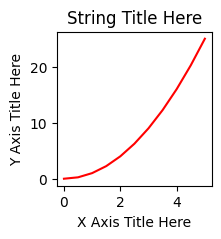

In [6]:
# Create a basic line plot: set figure size, plot x vs y in red, add axis labels and title
plt.figure(figsize=(2,2))         # Set display figure size (width, height in inches)
plt.plot(x, y, 'r')               # 'r' = red line, plots y values against x
plt.xlabel('X Axis Title Here')   # Label for x-axis
plt.ylabel('Y Axis Title Here')   # Label for y-axis
plt.title('String Title Here')    # Plot title
plt.show()                        # Display the figure

## Creating Multiplots on Same Canvas

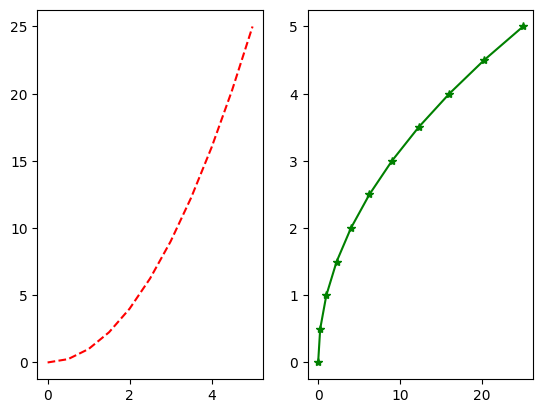

In [7]:
# Create multiple subplots on the same canvas: 1 row, 2 columns
# plt.subplot(nrows, ncols, plot_number) - activate subplot by index
plt.subplot(1,2,1)                # First subplot: x vs y with red dashed line
plt.plot(x, y, 'r--')             # 'r--' = red dashed line

plt.subplot(1,2,2)                # Second subplot: y vs x with green line and star markers
plt.plot(y, x, 'g*-');            # 'g*-' = green line with star markers

___
# Matplotlib Object Oriented Method
Now that we've seen the basics, let's break it all down with a more formal introduction of Matplotlib's Object Oriented API. This means we will instantiate figure objects and then call methods or attributes from that object.

## Introduction to the Object Oriented Method

The main idea in using the more formal Object Oriented method is to create figure objects and then just call methods or attributes off of that object. This approach is nicer when dealing with a canvas that has multiple plots on it. 

To begin we create a figure instance. Then we can add axes to that figure:

Text(0.5, 1.0, 'Set Title')

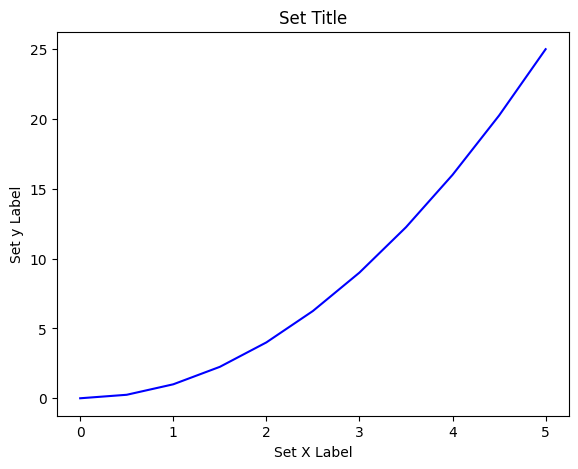

In [8]:
# Object-oriented approach: create figure object, add axes, then plot
# Create Figure - an empty canvas to hold our plot
fig = plt.figure()
# Add axes: [left, bottom, width, height] - all in range 0 to 1 (fraction of figure)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# Plot on the axes object - gives us full control over the plot
axes.plot(x, y, 'b')
axes.set_xlabel('Set X Label') # Notice the use of set_ to begin methods
axes.set_ylabel('Set y Label')
axes.set_title('Set Title')

Code is a little more complicated, but the advantage is that we now have full control of where the plot axes are placed, and we can easily add more than one axis to the figure:

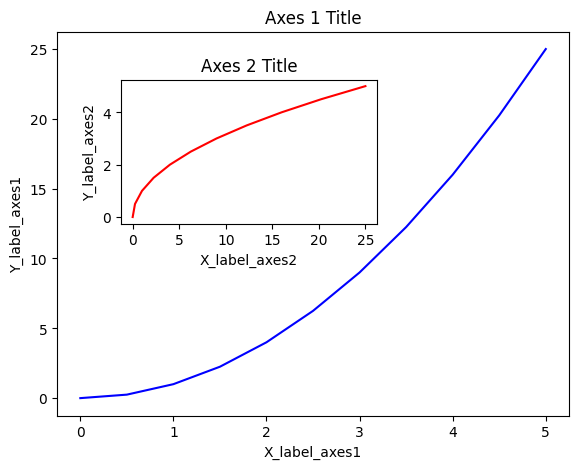

In [9]:
# Demonstrates multiple axes on one figure: main plot + inset
# Creates blank canvas
fig = plt.figure()
# Main axes (larger, full plot area)
axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# Inset axes (smaller plot inside main plot)
axes2 = fig.add_axes([0.2, 0.5, 0.4, 0.3])

# Larger Figure Axes 1
axes1.plot(x, y, 'b')
axes1.set_xlabel('X_label_axes1')
axes1.set_ylabel('Y_label_axes1')
axes1.set_title('Axes 1 Title')

# Insert Figure Axes 2
axes2.plot(y, x, 'r')
axes2.set_xlabel('X_label_axes2')
axes2.set_ylabel('Y_label_axes2')
axes2.set_title('Axes 2 Title');

## subplots()

The plt.subplots() object will act as a more automatic axis manager.

Basic use cases:

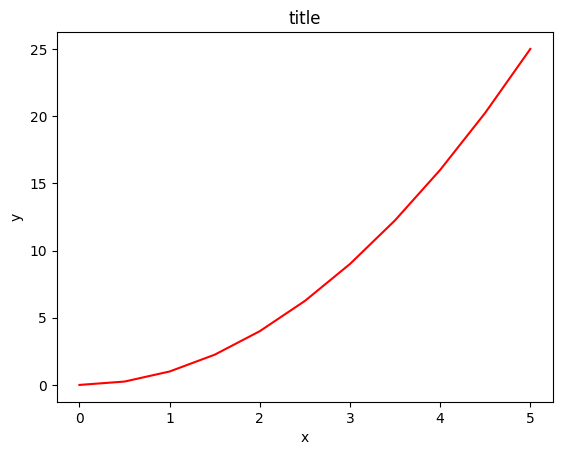

In [10]:
# plt.subplots() creates figure and axes in one call; tuple unpacking assigns both
# Use similar to plt.figure() except use tuple unpacking to grab fig and axes
fig, axes = plt.subplots()
# Now use the axes object to add stuff to plot (same as add_axes but automatic)
axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title');

Then you can specify the number of rows and columns when creating the subplots() object:

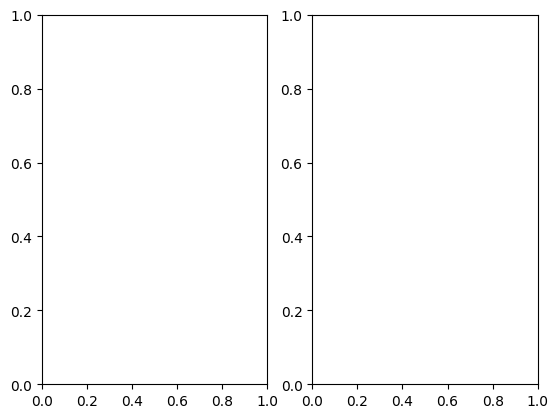

In [11]:
# Create a grid of subplots: 1 row, 2 columns; axes is an array of axis objects
fig, axes = plt.subplots(nrows=1, ncols=2)

In [12]:
# Display the axes array - shows we have 2 axis objects to plot on (index 0 and 1)
axes

array([<Axes: >, <Axes: >], dtype=object)

We can iterate through this array:

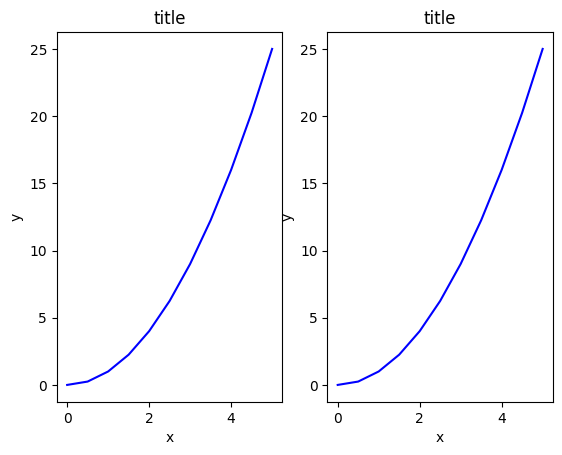

In [13]:
# Loop through each subplot and add the same plot (x vs y) with labels and title
for ax in axes:
    ax.plot(x, y, 'b')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

# Display the figure object    
fig

A common issue with matplolib is overlapping subplots or figures. We ca use **fig.tight_layout()** or **plt.tight_layout()** method, which automatically adjusts the positions of the axes on the figure canvas so that there is no overlapping content:

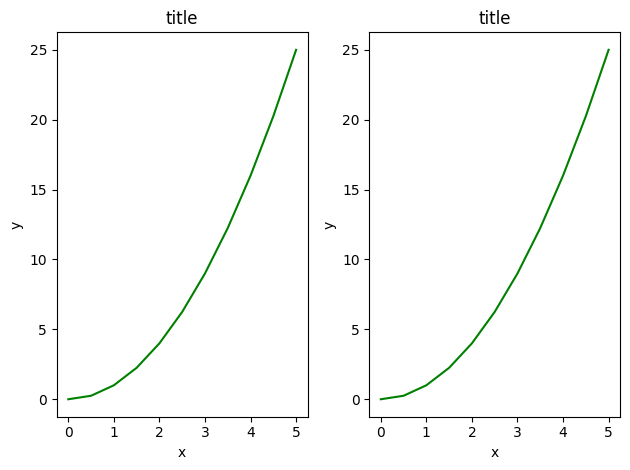

In [14]:
# tight_layout() automatically adjusts subplot params to prevent overlapping
fig, axes = plt.subplots(nrows=1, ncols=2)
for ax in axes:
    ax.plot(x, y, 'g')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

fig    
plt.tight_layout()

### Figure size, aspect ratio and DPI

Matplotlib allows the aspect ratio, DPI and figure size to be specified when the Figure object is created. You can use the `figsize` and `dpi` keyword arguments. 
* `figsize` is a tuple of the width and height of the figure in inches
* `dpi` is the dots-per-inch (pixel per inch). 

For example:

In [15]:
# Set figure size (width, height in inches) and DPI (dots per inch for resolution)
fig = plt.figure(figsize=(8,4), dpi=100)

<Figure size 800x400 with 0 Axes>

The same arguments can also be passed to layout managers, such as the `subplots` function:

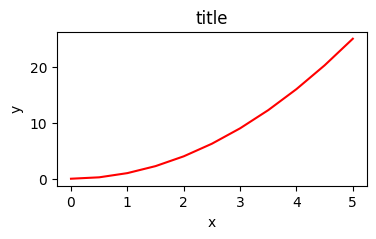

In [16]:
# Pass figsize directly to subplots for a compact figure
fig, axes = plt.subplots(figsize=(4,2))

axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title');

## Saving figures
Matplotlib can generate high-quality output in a number formats, including PNG, JPG, EPS, SVG, PGF and PDF. 

To save a figure to a file we can use the `savefig` method in the `Figure` class:

In [17]:
# Save the current figure to a file (PNG format by default)
fig.savefig("filename.png")

Here we can also optionally specify the DPI and choose between different output formats:

In [18]:
# Save with higher DPI (200) for better resolution/quality
fig.savefig("filename.png", dpi=200)

____
## Legends, labels and titles

Now that we have covered the basics of how to create a figure canvas and add axes instances to the canvas, let's look at how decorate a figure with titles, axis labels, and legends.

**Figure titles**

A title can be added to each axis instance in a figure. To set the title, use the `set_title` method in the axes instance:

In [19]:
# Method to set the title on an axis object (example usage)
ax.set_title("title");

**Axis labels**

Similarly, with the methods `set_xlabel` and `set_ylabel`, we can set the labels of the X and Y axes:

In [20]:
# Methods to set labels for the x and y axes on an axis object
ax.set_xlabel("x")
ax.set_ylabel("y");

### Legends

You can use the **label="label text"** keyword argument when plots or other objects are added to the figure, and then using the **legend** method without arguments to add the legend to the figure: 

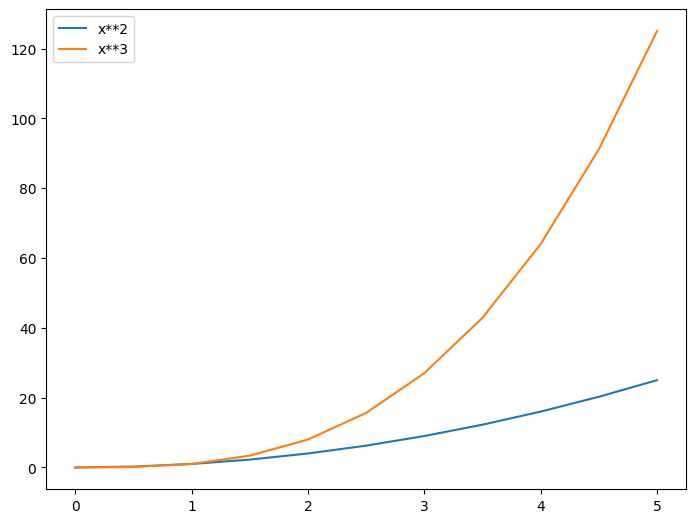

In [21]:
# Using labels with plots enables a legend - assign label to each plot, then call legend()
fig = plt.figure()
ax = fig.add_axes([0,0,1,1]) 
ax.plot(x, x**2, label="x**2")
ax.plot(x, x**3, label="x**3")
ax.legend()

Notice how are legend overlaps some of the actual plot!

The **legend** function takes an optional keyword argument **loc** that can be used to specify where in the figure the legend is to be drawn. The allowed values of **loc** are numerical codes for the various places the legend can be drawn. See the [documentation page](https://matplotlib.org/stable/) for details. Some of the most common **loc** values are:

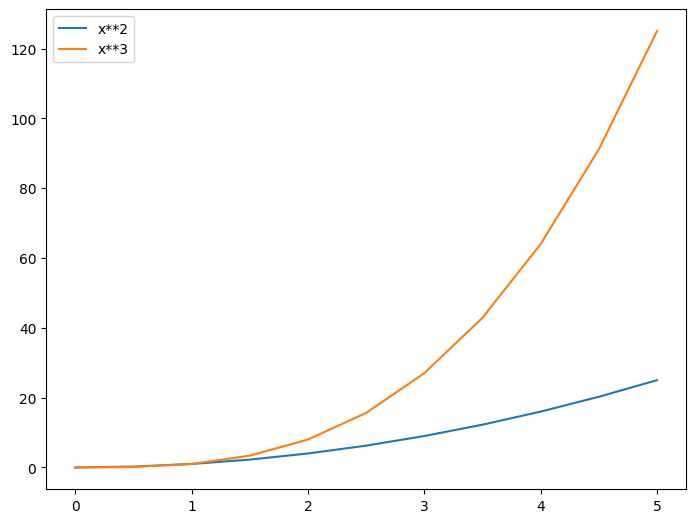

In [22]:
# Lots of options....

ax.legend(loc=1) # upper right corner
ax.legend(loc=2) # upper left corner
ax.legend(loc=3) # lower left corner
ax.legend(loc=4) # lower right corner

# .. many more options are available

# Most common to choose
ax.legend(loc=0) # let matplotlib decide the optimal location
fig

## Setting colors, linewidths, linetypes

Matplotlib gives you *a lot* of options for customizing colors, linewidths, and linetypes. 

There is the basic MATLAB like syntax (which I would suggest you avoid using for more clairty sake:

### Colors with MatLab like syntax

With matplotlib, we can define the colors of lines and other graphical elements in a number of ways. First of all, we can use the MATLAB-like syntax where `'b'` means blue, `'g'` means green, etc. The MATLAB API for selecting line styles are also supported: where, for example, 'b.-' means a blue line with dots:

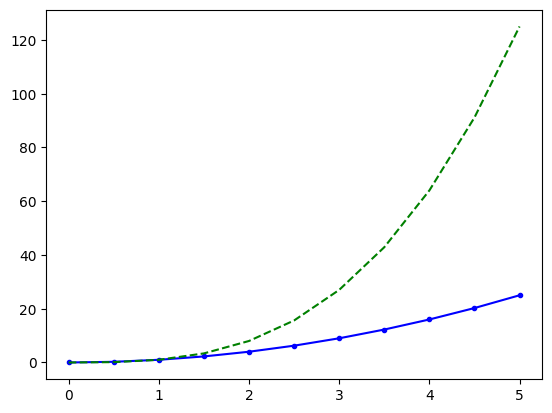

In [23]:
# MATLAB-style format string: color + line style + marker (e.g. 'b.-' = blue line with dots)
fig, ax = plt.subplots()
ax.plot(x, x**2, 'b.-') # blue line with dots
ax.plot(x, x**3, 'g--') # green dashed line

### Colors with the color= parameter

We can also define colors by their names or RGB hex codes and optionally provide an alpha value using the `color` and `alpha` keyword arguments. Alpha indicates opacity.

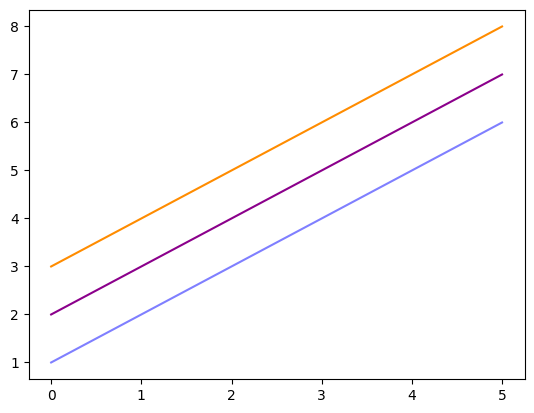

In [24]:
# Using color= parameter: name, hex code, or RGB; alpha controls transparency (0-1)
fig, ax = plt.subplots()
ax.plot(x, x+1, color="blue", alpha=0.5)  # half-transparent # half-transparant
ax.plot(x, x+2, color="#8B008B")        # RGB hex code
ax.plot(x, x+3, color="#FF8C00")        # RGB hex code 

### Line and marker styles

To change the line width, we can use the `linewidth` or `lw` keyword argument. The line style can be selected using the `linestyle` or `ls` keyword arguments:

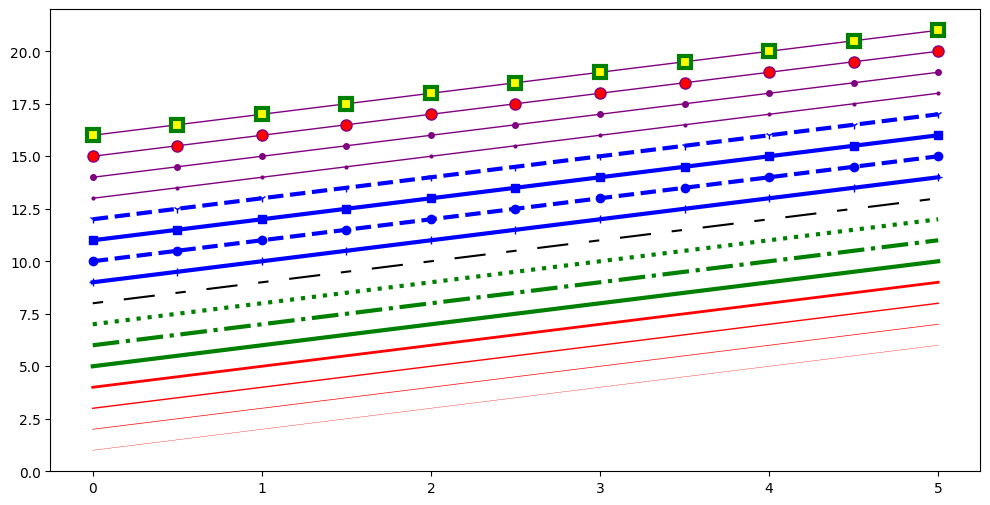

In [25]:
# linewidth/lw and linestyle/ls: control appearance of lines
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(x, x+1, color="red", linewidth=0.25)
ax.plot(x, x+2, color="red", linewidth=0.50)
ax.plot(x, x+3, color="red", linewidth=1.00)
ax.plot(x, x+4, color="red", linewidth=2.00)

# possible linestype options ‘-‘, ‘–’, ‘-.’, ‘:’, ‘steps’
ax.plot(x, x+5, color="green", lw=3, linestyle='-')
ax.plot(x, x+6, color="green", lw=3, ls='-.')
ax.plot(x, x+7, color="green", lw=3, ls=':')

# custom dash
line, = ax.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10]) # format: line length, space length, ...

# possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x+ 9, color="blue", lw=3, ls='-', marker='+')
ax.plot(x, x+10, color="blue", lw=3, ls='--', marker='o')
ax.plot(x, x+11, color="blue", lw=3, ls='-', marker='s')
ax.plot(x, x+12, color="blue", lw=3, ls='--', marker='1')

# marker size and color
ax.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
ax.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
ax.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
ax.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8, 
        markerfacecolor="yellow", markeredgewidth=3, markeredgecolor="green");

### Control over axis appearance

In this section we will look at controlling axis sizing properties in a matplotlib figure.

## Plot range

We can configure the ranges of the axes using the `set_ylim` and `set_xlim` methods in the axis object, or `axis('tight')` for automatically getting "tightly fitted" axes ranges:

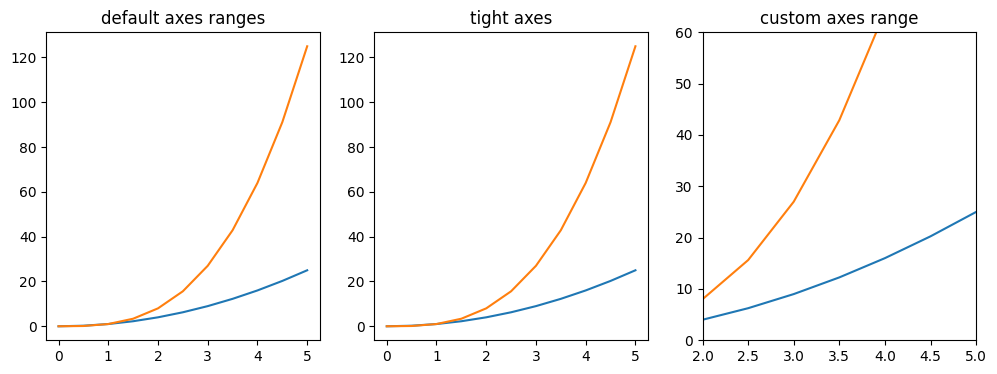

In [26]:
# Axis range control: default, axis('tight'), or manual set_ylim/set_xlim
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(x, x**2, x, x**3)
axes[0].set_title("default axes ranges")

axes[1].plot(x, x**2, x, x**3)
axes[1].axis('tight')
axes[1].set_title("tight axes")

axes[2].plot(x, x**2, x, x**3)
axes[2].set_ylim([0, 60])
axes[2].set_xlim([2, 5])
axes[2].set_title("custom axes range");

# Special Plot Types

There are many specialized plots we can create, such as barplots, histograms, scatter plots, and much more. Most of these type of plots we will actually create using seaborn, a statistical plotting library for Python. But here are a few examples of these type of plots:

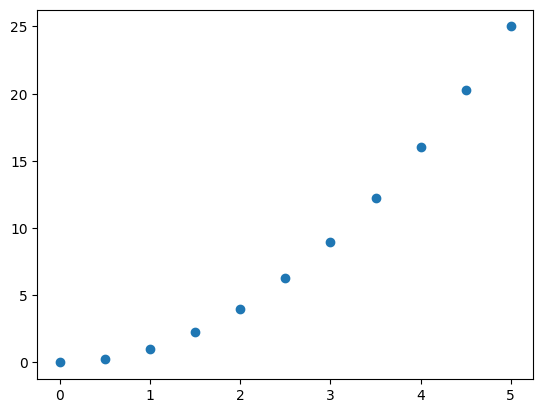

In [27]:
# Scatter plot: shows individual points instead of connected lines (x vs y)
plt.scatter(x,y)

(array([10., 10.,  6., 11., 12., 16.,  8.,  9., 10.,  8.]),
 array([ 15. , 112.1, 209.2, 306.3, 403.4, 500.5, 597.6, 694.7, 791.8,
        888.9, 986. ]),
 <BarContainer object of 10 artists>)

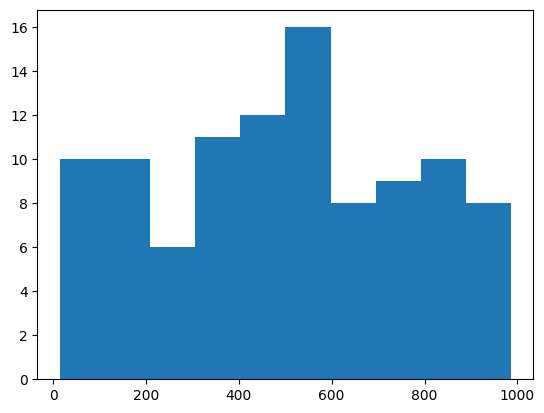

In [28]:
# Histogram: shows distribution of data; sample 100 random integers and plot frequency
from random import sample
data = sample(range(1, 1000), 100)
plt.hist(data)

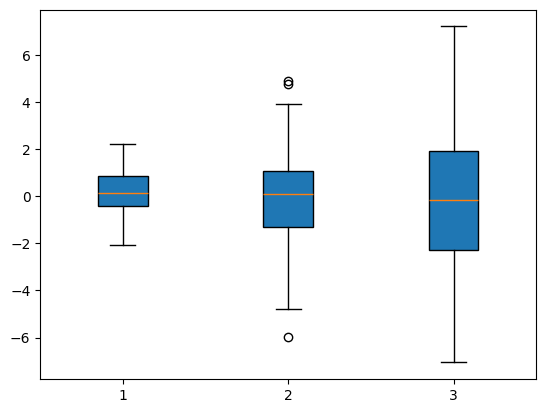

In [29]:
# Box plot: shows distribution (quartiles, median, outliers) for multiple datasets
# Create 3 datasets with different standard deviations (normal distribution)
data = [np.random.normal(0, std, 100) for std in range(1, 4)]
# vert=True: vertical boxes; patch_artist=True: allows coloring the boxes
plt.boxplot(data,vert=True,patch_artist=True);   

## References

* http://www.matplotlib.org - The project web page for matplotlib.
* https://github.com/matplotlib/matplotlib - The source code for matplotlib.
* http://matplotlib.org/gallery.html - A large gallery showcaseing various types of plots matplotlib can create. Highly recommended! 
* http://www.loria.fr/~rougier/teaching/matplotlib - A good matplotlib tutorial.
* http://scipy-lectures.github.io/matplotlib/matplotlib.html - Another good matplotlib reference.